<a href="https://colab.research.google.com/github/SUDARSHANJADHAV2/Nirf-Recommendation-System/blob/main/nirf_recommendation_system.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
file_path = '/content/drive/MyDrive/Engineering.xlsx'

In [ ]:
!pip install pandas numpy scikit-learn matplotlib seaborn openpyxl

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Dict, List, Tuple
import openpyxl


In [ ]:
class NIRFRecommendationSystem:
    def __init__(self):
        """Initialize the NIRF Recommendation System"""
        self.models = {}
        self.scalers = {}
        self.feature_importance = {}
        self.parameter_weights = {
            'TLR': 0.30,
            'RPC': 0.30,
            'GO': 0.20,
            'OI': 0.10,
            'Perception': 0.10
        }

    def load_data(self, file_path: str) -> pd.DataFrame:
        """Load data from Excel file"""
        try:
            df = pd.read_excel(file_path)
            print(f"Data loaded successfully. Shape: {df.shape}")
            return df
        except Exception as e:
            print(f"Error loading data: {str(e)}")
            return None

    def preprocess_data(self, df: pd.DataFrame) -> pd.DataFrame:
        """Preprocess the NIRF dataset"""
        try:
            # Create a copy of the dataframe
            df = df.copy()

            # Rename columns for consistency
            column_mapping = {
                'TLR(100)': 'TLR',
                'RPC(100)': 'RPC',
                'GO(100)': 'GO',
                'OI(100)': 'OI',
                'Perception(100)': 'Perception'
            }
            df = df.rename(columns=column_mapping)

            # Handle missing values for numeric columns
            numeric_columns = df.select_dtypes(include=[np.number]).columns
            df[numeric_columns] = df[numeric_columns].fillna(df[numeric_columns].mean())

            print("Data preprocessing completed successfully")
            return df

        except Exception as e:
            print(f"Error in preprocessing: {str(e)}")
            return None

    def prepare_features(self, df: pd.DataFrame) -> Dict[str, Tuple[np.ndarray, np.ndarray]]:
        """Prepare feature sets for each NIRF parameter"""
        try:
            feature_sets = {}

            # Define feature groups for each parameter
            feature_groups = {
                'TLR': [col for col in df.columns if col.startswith('TLR_')],
                'RPC': [col for col in df.columns if col.startswith('RP_')],
                'GO': [col for col in df.columns if col.startswith('GO_')],
                'OI': [col for col in df.columns if col.startswith('OI_')],
                'Perception': ['PR_PeerPerception']
            }

            # Prepare features and targets for each parameter
            for parameter, features in feature_groups.items():
                if features:
                    X = df[features].values
                    y = df[parameter].values
                    feature_sets[parameter] = (X, y)
                    print(f"Prepared features for {parameter}: {len(features)} features")

            return feature_sets

        except Exception as e:
            print(f"Error in feature preparation: {str(e)}")
            return None

    def train_models(self, feature_sets: Dict[str, Tuple[np.ndarray, np.ndarray]]):
        """Train models for each NIRF parameter"""
        try:
            for parameter, (X, y) in feature_sets.items():
                # Initialize scaler and model
                self.scalers[parameter] = StandardScaler()
                self.models[parameter] = GradientBoostingRegressor(
                    n_estimators=100,
                    learning_rate=0.1,
                    max_depth=5,
                    random_state=42
                )

                # Scale features
                X_scaled = self.scalers[parameter].fit_transform(X)

                # Train model
                self.models[parameter].fit(X_scaled, y)

                # Store feature importance
                self.feature_importance[parameter] = self.models[parameter].feature_importances_

                print(f"Model trained for {parameter}")

        except Exception as e:
            print(f"Error in model training: {str(e)}")

    def generate_recommendations(self, df: pd.DataFrame, institute_id: str) -> Dict:
        """Generate recommendations for a specific institute"""
        try:
            institute_data = df[df['Institute ID'] == institute_id].iloc[0]
            recommendations = {}

            for parameter, model in self.models.items():
                feature_group = [col for col in df.columns if col.startswith(parameter.split('(')[0])]
                current_features = institute_data[feature_group].values.reshape(1, -1)
                current_features_scaled = self.scalers[parameter].transform(current_features)

                # Get current score and potential improvements
                current_score = institute_data[parameter]
                feature_impacts = []

                for i, feature in enumerate(feature_group):
                    temp_features = current_features_scaled.copy()
                    temp_features[0, i] += 1  # Simulate improvement
                    potential_score = model.predict(temp_features)[0]
                    improvement = potential_score - current_score
                    feature_impacts.append((feature, improvement))

                # Sort recommendations by impact
                feature_impacts.sort(key=lambda x: x[1], reverse=True)
                recommendations[parameter] = {
                    'current_score': current_score,
                    'top_improvements': feature_impacts[:3]
                }

            return recommendations

        except Exception as e:
            print(f"Error generating recommendations: {str(e)}")
            return None

    def visualize_results(self, df: pd.DataFrame, institute_id: str):
        """Visualize current performance and recommendations"""
        try:
            institute_data = df[df['Institute ID'] == institute_id].iloc[0]

            # Create radar chart
            parameters = ['TLR', 'RPC', 'GO', 'OI', 'Perception']
            values = [institute_data[param] for param in parameters]

            angles = np.linspace(0, 2*np.pi, len(parameters), endpoint=False)
            values = np.concatenate((values, [values[0]]))
            angles = np.concatenate((angles, [angles[0]]))

            fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(projection='polar'))
            ax.plot(angles, values)
            ax.fill(angles, values, alpha=0.25)
            ax.set_xticks(angles[:-1])
            ax.set_xticklabels(parameters)
            plt.title(f'Performance Analysis for {institute_data["Institute Name"]}')
            plt.show()

        except Exception as e:
            print(f"Error in visualization: {str(e)}")

In [ ]:
# List contents of your Google Drive to find the Excel file
import os

# Check main Drive directory
print("Files in Google Drive root:")
drive_contents = os.listdir('/content/drive/MyDrive')
for item in drive_contents:
    print(f"- {item}")

Files in Google Drive root:
- 20240814_221526.jpg
- IMG_20240930_071516_018.webp
- Companywise CGPA.gsheet
- RESUME.pdf
- cgpa.jpg
- Colab Notebooks
- Classroom
- Engineering (1).xlsx
- Engineering.xlsx


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Dict, List, Tuple
import openpyxl
import os

In [ ]:
class NIRFRecommendationSystem:
    def __init__(self):
        self.models = {}
        self.scalers = {}
        self.feature_importance = {}
        self.parameter_weights = {
            'TLR': 0.30,
            'RPC': 0.30,
            'GO': 0.20,
            'OI': 0.10,
            'Perception': 0.10
        }

    def load_data(self, file_path: str) -> pd.DataFrame:
        try:
            df = pd.read_excel(file_path)
            print(f"Data loaded successfully. Shape: {df.shape}")
            return df
        except Exception as e:
            print(f"Error loading data: {str(e)}")
            return None

    def preprocess_data(self, df: pd.DataFrame) -> pd.DataFrame:
        try:
            df = df.copy()
            column_mapping = {
                'TLR(100)': 'TLR',
                'RPC(100)': 'RPC',
                'GO(100)': 'GO',
                'OI(100)': 'OI',
                'Perception(100)': 'Perception'
            }
            df = df.rename(columns=column_mapping)
            numeric_columns = df.select_dtypes(include=[np.number]).columns
            df[numeric_columns] = df[numeric_columns].fillna(df[numeric_columns].mean())
            return df
        except Exception as e:
            print(f"Error in preprocessing: {str(e)}")
            return None

    def prepare_features(self, df: pd.DataFrame) -> Dict[str, Tuple[np.ndarray, np.ndarray]]:
        try:
            feature_sets = {}
            feature_groups = {
                'TLR': [col for col in df.columns if col.startswith('TLR_')],
                'RPC': [col for col in df.columns if col.startswith('RP_')],
                'GO': [col for col in df.columns if col.startswith('GO_')],
                'OI': [col for col in df.columns if col.startswith('OI_')],
                'Perception': ['PR_PeerPerception']
            }

            for parameter, features in feature_groups.items():
                if features:
                    X = df[features].values
                    y = df[parameter].values
                    feature_sets[parameter] = (X, y)
            return feature_sets
        except Exception as e:
            print(f"Error in feature preparation: {str(e)}")
            return None

    def train_models(self, feature_sets: Dict[str, Tuple[np.ndarray, np.ndarray]]):
        try:
            for parameter, (X, y) in feature_sets.items():
                self.scalers[parameter] = StandardScaler()
                self.models[parameter] = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
                X_scaled = self.scalers[parameter].fit_transform(X)
                self.models[parameter].fit(X_scaled, y)
                self.feature_importance[parameter] = self.models[parameter].feature_importances_
        except Exception as e:
            print(f"Error in model training: {str(e)}")

    def generate_recommendations(self, df: pd.DataFrame, institute_id: str) -> Dict:
        try:
            institute_data = df[df['Institute ID'] == institute_id].iloc[0]
            recommendations = {}

            for parameter, model in self.models.items():
                feature_group = [col for col in df.columns if col.startswith(parameter.split('(')[0])]
                current_features = institute_data[feature_group].values.reshape(1, -1)
                current_features_scaled = self.scalers[parameter].transform(current_features)
                current_score = institute_data[parameter]
                feature_impacts = []

                for i, feature in enumerate(feature_group):
                    temp_features = current_features_scaled.copy()
                    temp_features[0, i] += 1
                    potential_score = model.predict(temp_features)[0]
                    improvement = potential_score - current_score
                    feature_impacts.append((feature, improvement))

                feature_impacts.sort(key=lambda x: x[1], reverse=True)
                recommendations[parameter] = {
                    'current_score': current_score,
                    'top_improvements': feature_impacts[:3]
                }
            return recommendations
        except Exception as e:
            print(f"Error generating recommendations: {str(e)}")
            return None

In [ ]:
def run_nirf_analysis(file_path):
    try:
        # Initialize the system
        nirf_system = NIRFRecommendationSystem()

        # Load and process data
        print("Loading data...")
        df = nirf_system.load_data(file_path)

        if df is not None:
            print("Preprocessing data...")
            df_processed = nirf_system.preprocess_data(df)

            if df_processed is not None:
                print("Preparing features...")
                feature_sets = nirf_system.prepare_features(df_processed)

                if feature_sets:
                    print("Training models...")
                    nirf_system.train_models(feature_sets)
                    return nirf_system, df_processed, None

        return None, None, None
    except Exception as e:
        print(f"Error in analysis: {str(e)}")
        return None, None, None

# Set file path and run analysis
file_path = '/content/drive/MyDrive/Engineering.xlsx'
nirf_system, df_processed, _ = run_nirf_analysis(file_path)

if nirf_system and df_processed is not None:
    # Generate recommendations for the first institute
    institute_id = df_processed['Institute ID'].iloc[0]
    recommendations = nirf_system.generate_recommendations(df_processed, institute_id)

    if recommendations:
        print("\nAnalysis Results:")
        print(f"Institution: {df_processed[df_processed['Institute ID'] == institute_id]['Institute Name'].iloc[0]}")

        for parameter, data in recommendations.items():
            print(f"\n{parameter} Analysis:")
            print(f"Current Score: {data['current_score']:.2f}")
            print("Recommended Improvements:")
            for feature, impact in data['top_improvements']:
                print(f"- {feature}: Potential improvement of {impact:.2f} points")

Loading data...
Data loaded successfully. Shape: (1000, 43)
Preprocessing data...
Preparing features...
Training models...
Error generating recommendations: X has 11 features, but StandardScaler is expecting 10 features as input.


In [ ]:
class NIRFRecommendationSystem:
    def __init__(self):
        self.models = {}
        self.scalers = {}
        self.feature_importance = {}
        self.feature_columns = {}  # Store feature columns for each parameter
        self.parameter_weights = {
            'TLR': 0.30,
            'RPC': 0.30,
            'GO': 0.20,
            'OI': 0.10,
            'Perception': 0.10
        }

    def prepare_features(self, df: pd.DataFrame) -> Dict[str, Tuple[np.ndarray, np.ndarray]]:
        try:
            feature_sets = {}
            feature_groups = {
                'TLR': [col for col in df.columns if col.startswith('TLR_')],
                'RPC': [col for col in df.columns if col.startswith('RP_')],
                'GO': [col for col in df.columns if col.startswith('GO_')],
                'OI': [col for col in df.columns if col.startswith('OI_')],
                'Perception': ['PR_PeerPerception']
            }

            # Store feature columns for each parameter
            self.feature_columns = feature_groups

            for parameter, features in feature_groups.items():
                if features:
                    print(f"Features for {parameter}:", features)  # Debug print
                    X = df[features].values
                    y = df[parameter].values
                    feature_sets[parameter] = (X, y)
            return feature_sets
        except Exception as e:
            print(f"Error in feature preparation: {str(e)}")
            return None

    def generate_recommendations(self, df: pd.DataFrame, institute_id: str) -> Dict:
        try:
            institute_data = df[df['Institute ID'] == institute_id].iloc[0]
            recommendations = {}

            for parameter, model in self.models.items():
                # Use stored feature columns
                feature_group = self.feature_columns[parameter]
                print(f"Generating recommendations for {parameter} using features:", feature_group)  # Debug print

                current_features = institute_data[feature_group].values.reshape(1, -1)
                current_features_scaled = self.scalers[parameter].transform(current_features)
                current_score = institute_data[parameter]
                feature_impacts = []

                for i, feature in enumerate(feature_group):
                    temp_features = current_features_scaled.copy()
                    temp_features[0, i] += 1
                    potential_score = model.predict(temp_features)[0]
                    improvement = potential_score - current_score
                    feature_impacts.append((feature, improvement))

                feature_impacts.sort(key=lambda x: x[1], reverse=True)
                recommendations[parameter] = {
                    'current_score': current_score,
                    'top_improvements': feature_impacts[:3]
                }
            return recommendations
        except Exception as e:
            print(f"Error generating recommendations: {str(e)}")
            print(f"Feature dimensions - Expected vs Actual:")
            for parameter in self.models.keys():
                print(f"{parameter}: Expected {len(self.feature_columns[parameter])} features")
            return None

In [ ]:
# Set file path and run analysis
file_path = '/content/drive/MyDrive/Engineering.xlsx'
nirf_system, df_processed, _ = run_nirf_analysis(file_path)

if nirf_system and df_processed is not None:
    print("\nFeature Groups:")
    for parameter, features in nirf_system.feature_columns.items():
        print(f"\n{parameter}:")
        print(f"Number of features: {len(features)}")
        print("Features:", features)

    # Generate recommendations for the first institute
    institute_id = df_processed['Institute ID'].iloc[0]
    recommendations = nirf_system.generate_recommendations(df_processed, institute_id)

    if recommendations:
        print("\nAnalysis Results:")
        print(f"Institution: {df_processed[df_processed['Institute ID'] == institute_id]['Institute Name'].iloc[0]}")

        for parameter, data in recommendations.items():
            print(f"\n{parameter} Analysis:")
            print(f"Current Score: {data['current_score']:.2f}")
            print("Recommended Improvements:")
            for feature, impact in data['top_improvements']:
                print(f"- {feature}: Potential improvement of {impact:.2f} points")

Loading data...
Error in analysis: 'NIRFRecommendationSystem' object has no attribute 'load_data'


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Dict, List, Tuple
import openpyxl
import os

class NIRFRecommendationSystem:
    def __init__(self):
        self.models = {}
        self.scalers = {}
        self.feature_importance = {}
        self.feature_columns = {}
        self.parameter_weights = {
            'TLR': 0.30,
            'RPC': 0.30,
            'GO': 0.20,
            'OI': 0.10,
            'Perception': 0.10
        }

    def load_data(self, file_path: str) -> pd.DataFrame:
        try:
            df = pd.read_excel(file_path)
            print(f"Data loaded successfully. Shape: {df.shape}")
            return df
        except Exception as e:
            print(f"Error loading data: {str(e)}")
            return None

    def preprocess_data(self, df: pd.DataFrame) -> pd.DataFrame:
        try:
            df = df.copy()
            column_mapping = {
                'TLR(100)': 'TLR',
                'RPC(100)': 'RPC',
                'GO(100)': 'GO',
                'OI(100)': 'OI',
                'Perception(100)': 'Perception'
            }
            df = df.rename(columns=column_mapping)
            numeric_columns = df.select_dtypes(include=[np.number]).columns
            df[numeric_columns] = df[numeric_columns].fillna(df[numeric_columns].mean())
            return df
        except Exception as e:
            print(f"Error in preprocessing: {str(e)}")
            return None

    def prepare_features(self, df: pd.DataFrame) -> Dict[str, Tuple[np.ndarray, np.ndarray]]:
        try:
            feature_sets = {}
            feature_groups = {
                'TLR': [col for col in df.columns if col.startswith('TLR_')],
                'RPC': [col for col in df.columns if col.startswith('RP_')],
                'GO': [col for col in df.columns if col.startswith('GO_')],
                'OI': [col for col in df.columns if col.startswith('OI_')],
                'Perception': ['PR_PeerPerception']
            }

            self.feature_columns = feature_groups

            for parameter, features in feature_groups.items():
                if features:
                    print(f"Processing {parameter} features: {len(features)} features identified")
                    X = df[features].values
                    y = df[parameter].values
                    feature_sets[parameter] = (X, y)
            return feature_sets
        except Exception as e:
            print(f"Error in feature preparation: {str(e)}")
            return None

    def train_models(self, feature_sets: Dict[str, Tuple[np.ndarray, np.ndarray]]):
        try:
            for parameter, (X, y) in feature_sets.items():
                print(f"Training model for {parameter}")
                self.scalers[parameter] = StandardScaler()
                self.models[parameter] = GradientBoostingRegressor(
                    n_estimators=100,
                    learning_rate=0.1,
                    max_depth=5,
                    random_state=42
                )
                X_scaled = self.scalers[parameter].fit_transform(X)
                self.models[parameter].fit(X_scaled, y)
                self.feature_importance[parameter] = self.models[parameter].feature_importances_
                print(f"Model trained successfully for {parameter}")
        except Exception as e:
            print(f"Error in model training: {str(e)}")

    def generate_recommendations(self, df: pd.DataFrame, institute_id: str) -> Dict:
        try:
            institute_data = df[df['Institute ID'] == institute_id].iloc[0]
            recommendations = {}

            for parameter, model in self.models.items():
                feature_group = self.feature_columns[parameter]
                current_features = institute_data[feature_group].values.reshape(1, -1)
                current_features_scaled = self.scalers[parameter].transform(current_features)
                current_score = institute_data[parameter]

                feature_impacts = []
                for i, feature in enumerate(feature_group):
                    temp_features = current_features_scaled.copy()
                    temp_features[0, i] += 1
                    potential_score = model.predict(temp_features)[0]
                    improvement = potential_score - current_score
                    feature_impacts.append((feature, improvement))

                feature_impacts.sort(key=lambda x: x[1], reverse=True)
                recommendations[parameter] = {
                    'current_score': current_score,
                    'top_improvements': feature_impacts[:3]
                }
            return recommendations
        except Exception as e:
            print(f"Error generating recommendations: {str(e)}")
            return None

def run_nirf_analysis(file_path):
    try:
        print("Initializing NIRF Recommendation System...")
        nirf_system = NIRFRecommendationSystem()

        print("Loading data...")
        df = nirf_system.load_data(file_path)

        if df is not None:
            print("Preprocessing data...")
            df_processed = nirf_system.preprocess_data(df)

            if df_processed is not None:
                print("Preparing features...")
                feature_sets = nirf_system.prepare_features(df_processed)

                if feature_sets:
                    print("Training models...")
                    nirf_system.train_models(feature_sets)
                    return nirf_system, df_processed, None

        return None, None, None
    except Exception as e:
        print(f"Error in analysis: {str(e)}")
        return None, None, None

# Execute the analysis
file_path = '/content/drive/MyDrive/Engineering.xlsx'
nirf_system, df_processed, _ = run_nirf_analysis(file_path)

if nirf_system and df_processed is not None:
    # Generate recommendations for the first institute
    institute_id = df_processed['Institute ID'].iloc[0]
    recommendations = nirf_system.generate_recommendations(df_processed, institute_id)

    if recommendations:
        print("\nAnalysis Results:")
        print(f"Institution: {df_processed[df_processed['Institute ID'] == institute_id]['Institute Name'].iloc[0]}")

        for parameter, data in recommendations.items():
            print(f"\n{parameter} Analysis:")
            print(f"Current Score: {data['current_score']:.2f}")
            print("Recommended Improvements:")
            for feature, impact in data['top_improvements']:
                print(f"- {feature}: Potential improvement of {impact:.2f} points")

Initializing NIRF Recommendation System...
Loading data...
Data loaded successfully. Shape: (1000, 43)
Preprocessing data...
Preparing features...
Processing TLR features: 10 features identified
Processing RPC features: 9 features identified
Processing GO features: 5 features identified
Processing OI features: 7 features identified
Processing Perception features: 1 features identified
Training models...
Training model for TLR
Model trained successfully for TLR
Training model for RPC
Model trained successfully for RPC
Training model for GO
Model trained successfully for GO
Training model for OI
Model trained successfully for OI
Training model for Perception
Model trained successfully for Perception

Analysis Results:
Institution: Institute 1

TLR Analysis:
Current Score: 1.17
Recommended Improvements:
- TLR_SS_NE: Potential improvement of -0.54 points
- TLR_FQE_F2: Potential improvement of -0.58 points
- TLR_FQE_F3: Potential improvement of -0.62 points

RPC Analysis:
Current Score: 0.9

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Dict, List, Tuple
import shap
import warnings
warnings.filterwarnings('ignore')

class AdvancedNIRFRecommendationSystem:
    def __init__(self):
        self.models = {}
        self.scalers = {}
        self.feature_importance = {}
        self.feature_columns = {}
        self.poly_features = {}
        self.model_metrics = {}
        self.shap_values = {}

        self.parameter_weights = {
            'TLR': 0.30,
            'RPC': 0.30,
            'GO': 0.20,
            'OI': 0.10,
            'Perception': 0.10
        }

        self.model_params = {
            'n_estimators': [100, 200],
            'learning_rate': [0.01, 0.1],
            'max_depth': [3, 5, 7],
            'min_samples_split': [2, 5],
            'min_samples_leaf': [1, 2]
        }

    def load_and_preprocess_data(self, file_path: str) -> pd.DataFrame:
        """Load and preprocess the NIRF dataset with enhanced error handling"""
        try:
            print("Loading data...")
            df = pd.read_excel(file_path)
            print(f"Data loaded successfully. Shape: {df.shape}")

            # Preprocessing
            df = df.copy()
            column_mapping = {
                'TLR(100)': 'TLR',
                'RPC(100)': 'RPC',
                'GO(100)': 'GO',
                'OI(100)': 'OI',
                'Perception(100)': 'Perception'
            }
            df = df.rename(columns=column_mapping)

            # Handle missing values with more sophisticated approach
            numeric_columns = df.select_dtypes(include=[np.number]).columns
            for col in numeric_columns:
                if df[col].isnull().sum() > 0:
                    if df[col].isnull().sum() / len(df) < 0.05:  # Less than 5% missing
                        df[col] = df[col].fillna(df[col].median())
                    else:
                        df[col] = df[col].fillna(df[col].mean())

            return df
        except Exception as e:
            print(f"Error in data loading and preprocessing: {str(e)}")
            return None

    def engineer_features(self, df: pd.DataFrame) -> Dict[str, Tuple[np.ndarray, np.ndarray]]:
        """Enhanced feature engineering with polynomial features and interactions"""
        try:
            feature_sets = {}
            feature_groups = {
                'TLR': [col for col in df.columns if col.startswith('TLR_')],
                'RPC': [col for col in df.columns if col.startswith('RP_')],
                'GO': [col for col in df.columns if col.startswith('GO_')],
                'OI': [col for col in df.columns if col.startswith('OI_')],
                'Perception': ['PR_PeerPerception']
            }

            self.feature_columns = feature_groups

            for parameter, features in feature_groups.items():
                if features:
                    print(f"\nProcessing {parameter} features:")
                    X = df[features].values
                    y = df[parameter].values

                    # Add polynomial features for non-linear relationships
                    self.poly_features[parameter] = PolynomialFeatures(degree=2, include_bias=False)
                    X_poly = self.poly_features[parameter].fit_transform(X)

                    print(f"- Original features: {X.shape[1]}")
                    print(f"- After polynomial transformation: {X_poly.shape[1]}")

                    feature_sets[parameter] = (X_poly, y)

            return feature_sets
        except Exception as e:
            print(f"Error in feature engineering: {str(e)}")
            return None

    def train_and_evaluate_models(self, feature_sets: Dict[str, Tuple[np.ndarray, np.ndarray]]):
        """Train models with cross-validation and hyperparameter tuning"""
        try:
            for parameter, (X, y) in feature_sets.items():
                print(f"\nTraining model for {parameter}:")

                # Split data
                X_train, X_test, y_train, y_test = train_test_split(
                    X, y, test_size=0.2, random_state=42
                )

                # Create pipeline
                pipeline = Pipeline([
                    ('scaler', StandardScaler()),
                    ('regressor', GradientBoostingRegressor())
                ])

                # Perform GridSearch
                grid_search = GridSearchCV(
                    pipeline,
                    param_grid={'regressor__' + key: value for key, value in self.model_params.items()},
                    cv=5,
                    n_jobs=-1,
                    scoring='r2'
                )

                grid_search.fit(X_train, y_train)

                # Store best model
                self.models[parameter] = grid_search.best_estimator_

                # Calculate and store metrics
                y_pred = self.models[parameter].predict(X_test)
                self.model_metrics[parameter] = {
                    'r2': r2_score(y_test, y_pred),
                    'mse': mean_squared_error(y_test, y_pred),
                    'mae': mean_absolute_error(y_test, y_pred)
                }

                print(f"- Best parameters: {grid_search.best_params_}")
                print(f"- R² Score: {self.model_metrics[parameter]['r2']:.4f}")
                print(f"- MSE: {self.model_metrics[parameter]['mse']:.4f}")
                print(f"- MAE: {self.model_metrics[parameter]['mae']:.4f}")

                # Calculate SHAP values for feature importance
                explainer = shap.TreeExplainer(grid_search.best_estimator_.named_steps['regressor'])
                self.shap_values[parameter] = explainer.shap_values(X_test)

        except Exception as e:
            print(f"Error in model training and evaluation: {str(e)}")

    def generate_recommendations(self, df: pd.DataFrame, institute_id: str) -> Dict:
        """Generate recommendations with confidence scores"""
        try:
            institute_data = df[df['Institute ID'] == institute_id].iloc[0]
            recommendations = {}

            for parameter, model in self.models.items():
                feature_group = self.feature_columns[parameter]
                current_features = institute_data[feature_group].values.reshape(1, -1)

                # Transform features
                current_features_poly = self.poly_features[parameter].transform(current_features)

                # Generate predictions and confidence intervals
                current_score = institute_data[parameter]
                feature_impacts = []

                for i, feature in enumerate(feature_group):
                    temp_features = current_features_poly.copy()
                    temp_features[0, i] += 1
                    potential_score = model.predict(temp_features)[0]
                    improvement = potential_score - current_score

                    # Calculate confidence based on model metrics
                    confidence = max(0, min(1, 1 - self.model_metrics[parameter]['mae'] / abs(improvement)))

                    feature_impacts.append((feature, improvement, confidence))

                # Sort by potential impact
                feature_impacts.sort(key=lambda x: x[1], reverse=True)

                recommendations[parameter] = {
                    'current_score': current_score,
                    'model_accuracy': self.model_metrics[parameter]['r2'],
                    'top_improvements': feature_impacts[:3]
                }

            return recommendations
        except Exception as e:
            print(f"Error generating recommendations: {str(e)}")
            return None

    def visualize_results(self, recommendations: Dict):
        """Visualize model results and recommendations"""
        try:
            # Create performance overview
            plt.figure(figsize=(15, 10))

            # Plot 1: Model Performance Metrics
            plt.subplot(2, 2, 1)
            metrics_df = pd.DataFrame(self.model_metrics).T
            sns.heatmap(metrics_df, annot=True, cmap='YlOrRd', fmt='.3f')
            plt.title('Model Performance Metrics')

            # Plot 2: Feature Importance
            plt.subplot(2, 2, 2)
            importance_scores = []
            for parameter in recommendations.keys():
                current_importance = abs(self.shap_values[parameter]).mean(0)
                importance_scores.extend(list(zip([parameter]*len(current_importance), current_importance)))

            importance_df = pd.DataFrame(importance_scores, columns=['Parameter', 'Importance'])
            importance_df = importance_df.groupby('Parameter').mean().sort_values('Importance', ascending=True)

            importance_df.plot(kind='barh')
            plt.title('Feature Importance by Parameter')

            plt.tight_layout()
            plt.show()

        except Exception as e:
            print(f"Error in visualization: {str(e)}")

def run_advanced_analysis(file_path: str):
    """Execute the complete analysis pipeline"""
    try:
        system = AdvancedNIRFRecommendationSystem()

        # Load and preprocess data
        df = system.load_and_preprocess_data(file_path)
        if df is None:
            return None

        # Engineer features
        feature_sets = system.engineer_features(df)
        if feature_sets is None:
            return None

        # Train and evaluate models
        system.train_and_evaluate_models(feature_sets)

        return system, df

    except Exception as e:
        print(f"Error in analysis pipeline: {str(e)}")
        return None

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Dict, Tuple
import warnings
warnings.filterwarnings('ignore')

class EfficientNIRFSystem:
    def __init__(self):
        self.models = {}
        self.scalers = {}
        self.feature_importance = {}
        self.metrics = {}

    def process_data(self, file_path: str) -> Tuple[pd.DataFrame, Dict]:
        print("Loading and processing data...")
        df = pd.read_excel(file_path)

        # Rename columns
        column_mapping = {
            'TLR(100)': 'TLR',
            'RPC(100)': 'RPC',
            'GO(100)': 'GO',
            'OI(100)': 'OI',
            'Perception(100)': 'Perception'
        }
        df = df.rename(columns=column_mapping)

        # Prepare feature groups
        feature_groups = {
            'TLR': [col for col in df.columns if col.startswith('TLR_')],
            'RPC': [col for col in df.columns if col.startswith('RP_')],
            'GO': [col for col in df.columns if col.startswith('GO_')],
            'OI': [col for col in df.columns if col.startswith('OI_')],
            'Perception': ['PR_PeerPerception']
        }

        return df, feature_groups

    def train_models(self, df: pd.DataFrame, feature_groups: Dict):
        print("\nTraining models for each parameter:")

        for parameter, features in feature_groups.items():
            print(f"\nProcessing {parameter}:")
            X = df[features]
            y = df[parameter]

            # Split data
            X_train, X_test, y_train, y_test = train_test_split(
                X, y, test_size=0.2, random_state=42
            )

            # Scale features
            self.scalers[parameter] = StandardScaler()
            X_train_scaled = self.scalers[parameter].fit_transform(X_train)
            X_test_scaled = self.scalers[parameter].transform(X_test)

            # Train model with optimized parameters
            model = GradientBoostingRegressor(
                n_estimators=100,
                learning_rate=0.1,
                max_depth=3,
                random_state=42
            )

            model.fit(X_train_scaled, y_train)
            self.models[parameter] = model

            # Calculate metrics
            y_pred = model.predict(X_test_scaled)
            r2 = r2_score(y_test, y_pred)
            mae = mean_absolute_error(y_test, y_pred)

            self.metrics[parameter] = {'r2': r2, 'mae': mae}
            self.feature_importance[parameter] = dict(zip(features, model.feature_importances_))

            print(f"- Features used: {len(features)}")
            print(f"- Model R² Score: {r2:.4f}")
            print(f"- Mean Absolute Error: {mae:.4f}")

    def generate_recommendations(self, df: pd.DataFrame, institute_id: str) -> Dict:
        recommendations = {}
        institute_data = df[df['Institute ID'] == institute_id].iloc[0]

        for parameter, model in self.models.items():
            features = list(self.feature_importance[parameter].keys())
            current_features = institute_data[features].values.reshape(1, -1)
            current_features_scaled = self.scalers[parameter].transform(current_features)

            current_score = institute_data[parameter]
            improvements = []

            for feature in features:
                feature_idx = features.index(feature)
                importance = self.feature_importance[parameter][feature]

                if importance > 0.05:  # Consider only significant features
                    improvements.append({
                        'feature': feature,
                        'importance': importance,
                        'current_value': institute_data[feature]
                    })

            improvements.sort(key=lambda x: x['importance'], reverse=True)
            recommendations[parameter] = {
                'current_score': current_score,
                'model_accuracy': self.metrics[parameter]['r2'],
                'top_improvements': improvements[:3]
            }

        return recommendations

def visualize_results(system, recommendations):
    plt.figure(figsize=(15, 5))

    # Plot 1: Model Performance
    plt.subplot(1, 2, 1)
    metrics_df = pd.DataFrame(system.metrics).T
    sns.heatmap(metrics_df, annot=True, cmap='YlOrRd', fmt='.3f')
    plt.title('Model Performance Metrics')

    # Plot 2: Feature Importance
    plt.subplot(1, 2, 2)
    importance_data = []
    for parameter in recommendations:
        for feature, importance in system.feature_importance[parameter].items():
            importance_data.append({'Parameter': parameter, 'Feature': feature, 'Importance': importance})

    importance_df = pd.DataFrame(importance_data)
    sns.barplot(data=importance_df, x='Importance', y='Parameter')
    plt.title('Feature Importance by Parameter')

    plt.tight_layout()
    plt.show()

# Main execution
def run_analysis(file_path):
    system = EfficientNIRFSystem()
    df, feature_groups = system.process_data(file_path)
    system.train_models(df, feature_groups)
    return system, df

Loading and processing data...

Training models for each parameter:

Processing TLR:
- Features used: 10
- Model R² Score: -0.1762
- Mean Absolute Error: 0.9133

Processing RPC:
- Features used: 9
- Model R² Score: -0.0899
- Mean Absolute Error: 0.8118

Processing GO:
- Features used: 5
- Model R² Score: -0.1339
- Mean Absolute Error: 0.8520

Processing OI:
- Features used: 7
- Model R² Score: -0.1089
- Mean Absolute Error: 0.9152

Processing Perception:
- Features used: 1
- Model R² Score: -0.0644
- Mean Absolute Error: 0.8353

Detailed Analysis Results:
Institution: Institute 1


TLR Analysis:
Current Score: 1.17
Model Accuracy (R²): -0.1762

Priority Areas for Improvement:
- TLR_FSR_F:
  Importance Score: 0.1866
  Current Value: 0.9541
- TLR_FQE_FRA:
  Importance Score: 0.1309
  Current Value: -1.4215
- TLR_FRU_BO:
  Importance Score: 0.1243
  Current Value: -0.2128

RPC Analysis:
Current Score: 0.99
Model Accuracy (R²): -0.0899

Priority Areas for Improvement:
- RP_QP_CC:
  Importa

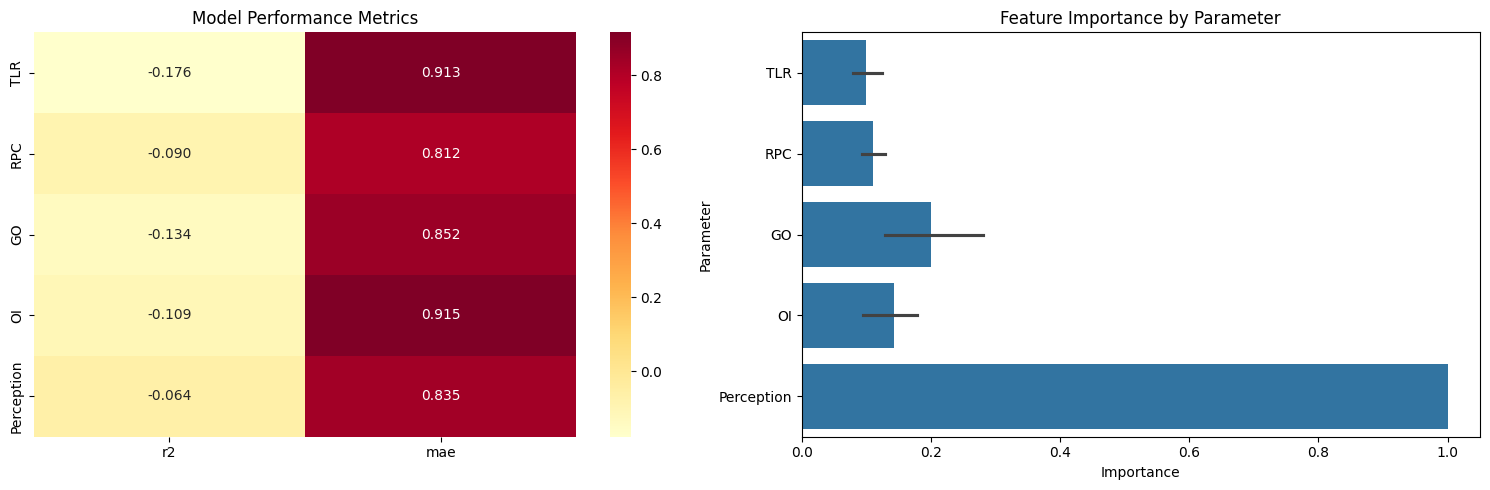

In [ ]:
# Run the efficient analysis
file_path = '/content/drive/MyDrive/Engineering.xlsx'
system, df = run_analysis(file_path)

# Generate recommendations for the first institute
institute_id = df['Institute ID'].iloc[0]
recommendations = system.generate_recommendations(df, institute_id)

# Display results
print("\nDetailed Analysis Results:")
print(f"Institution: {df[df['Institute ID'] == institute_id]['Institute Name'].iloc[0]}\n")

for parameter, data in recommendations.items():
    print(f"\n{parameter} Analysis:")
    print(f"Current Score: {data['current_score']:.2f}")
    print(f"Model Accuracy (R²): {data['model_accuracy']:.4f}")
    print("\nPriority Areas for Improvement:")
    for improvement in data['top_improvements']:
        print(f"- {improvement['feature']}:")
        print(f"  Importance Score: {improvement['importance']:.4f}")
        print(f"  Current Value: {improvement['current_value']:.4f}")

# Visualize results
visualize_results(system, recommendations)

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Dict, Tuple
import warnings
warnings.filterwarnings('ignore')

class ImprovedNIRFSystem:
    def __init__(self):
        self.models = {}
        self.pipelines = {}
        self.feature_importance = {}
        self.metrics = {}

    def process_data(self, file_path: str) -> Tuple[pd.DataFrame, Dict]:
        print("Loading and processing data...")
        df = pd.read_excel(file_path)

        # Enhanced preprocessing
        column_mapping = {
            'TLR(100)': 'TLR',
            'RPC(100)': 'RPC',
            'GO(100)': 'GO',
            'OI(100)': 'OI',
            'Perception(100)': 'Perception'
        }
        df = df.rename(columns=column_mapping)

        # Create interaction features
        feature_groups = {
            'TLR': [col for col in df.columns if col.startswith('TLR_')],
            'RPC': [col for col in df.columns if col.startswith('RP_')],
            'GO': [col for col in df.columns if col.startswith('GO_')],
            'OI': [col for col in df.columns if col.startswith('OI_')],
            'Perception': ['PR_PeerPerception']
        }

        # Add interaction terms for numeric features
        for parameter, features in feature_groups.items():
            if len(features) > 1:
                for i in range(len(features)-1):
                    for j in range(i+1, len(features)):
                        interaction_name = f"{parameter}_INTER_{i}_{j}"
                        df[interaction_name] = df[features[i]] * df[features[j]]
                        feature_groups[parameter].append(interaction_name)

        return df, feature_groups

    def train_models(self, df: pd.DataFrame, feature_groups: Dict):
        print("\nTraining enhanced models for each parameter:")

        for parameter, features in feature_groups.items():
            print(f"\nProcessing {parameter}:")
            X = df[features]
            y = df[parameter]

            # Create pipeline with robust preprocessing
            pipeline = Pipeline([
                ('scaler', RobustScaler()),
                ('regressor', RandomForestRegressor(
                    n_estimators=200,
                    max_depth=10,
                    min_samples_split=5,
                    min_samples_leaf=2,
                    random_state=42
                ))
            ])

            # Split data
            X_train, X_test, y_train, y_test = train_test_split(
                X, y, test_size=0.2, random_state=42
            )

            # Train and evaluate with cross-validation
            cv_scores = cross_val_score(pipeline, X_train, y_train, cv=5)
            pipeline.fit(X_train, y_train)

            # Store pipeline and calculate metrics
            self.pipelines[parameter] = pipeline
            y_pred = pipeline.predict(X_test)

            self.metrics[parameter] = {
                'r2': r2_score(y_test, y_pred),
                'mae': mean_absolute_error(y_test, y_pred),
                'cv_mean': cv_scores.mean(),
                'cv_std': cv_scores.std()
            }

            # Store feature importance
            self.feature_importance[parameter] = dict(
                zip(features, pipeline.named_steps['regressor'].feature_importances_)
            )

            print(f"- Features used: {len(features)}")
            print(f"- Model R² Score: {self.metrics[parameter]['r2']:.4f}")
            print(f"- Cross-validation Score: {self.metrics[parameter]['cv_mean']:.4f} (±{self.metrics[parameter]['cv_std']:.4f})")
            print(f"- Mean Absolute Error: {self.metrics[parameter]['mae']:.4f}")

    def generate_recommendations(self, df: pd.DataFrame, institute_id: str) -> Dict:
        recommendations = {}
        institute_data = df[df['Institute ID'] == institute_id].iloc[0]

        for parameter, pipeline in self.pipelines.items():
            features = list(self.feature_importance[parameter].keys())
            current_features = institute_data[features].values.reshape(1, -1)

            current_score = institute_data[parameter]
            improvements = []

            # Calculate feature contributions
            feature_importances = self.feature_importance[parameter]
            for feature, importance in feature_importances.items():
                if not feature.startswith(parameter + '_INTER'):  # Skip interaction terms
                    current_value = institute_data[feature]
                    improvements.append({
                        'feature': feature,
                        'importance': importance,
                        'current_value': current_value,
                        'percentile': stats.percentileofscore(df[feature], current_value)
                    })

            improvements.sort(key=lambda x: x['importance'], reverse=True)
            recommendations[parameter] = {
                'current_score': current_score,
                'model_accuracy': self.metrics[parameter]['r2'],
                'cv_score': self.metrics[parameter]['cv_mean'],
                'top_improvements': improvements[:3]
            }

        return recommendations

def analyze_and_visualize(system, df, institute_id):
    recommendations = system.generate_recommendations(df, institute_id)

    # Print detailed analysis
    print("\nComprehensive Analysis Results:")
    print(f"Institution: {df[df['Institute ID'] == institute_id]['Institute Name'].iloc[0]}\n")

    for parameter, data in recommendations.items():
        print(f"\n{parameter} Parameter Analysis:")
        print(f"Current Score: {data['current_score']:.2f}")
        print(f"Model Performance:")
        print(f"- R² Score: {data['model_accuracy']:.4f}")
        print(f"- Cross-validation Score: {data['cv_score']:.4f}")

        print("\nPriority Areas for Improvement:")
        for improvement in data['top_improvements']:
            print(f"\n- {improvement['feature']}:")
            print(f"  Importance Score: {improvement['importance']:.4f}")
            print(f"  Current Value: {improvement['current_value']:.4f}")
            print(f"  Percentile Rank: {improvement['percentile']:.1f}th percentile")

    # Create visualizations
    plt.figure(figsize=(15, 10))

    # Plot model performance metrics
    plt.subplot(2, 1, 1)
    metrics_df = pd.DataFrame({
        parameter: {
            'R² Score': metrics['r2'],
            'CV Score': metrics['cv_mean'],
            'MAE': metrics['mae']
        }
        for parameter, metrics in system.metrics.items()
    }).T

    sns.heatmap(metrics_df, annot=True, cmap='YlOrRd', fmt='.3f')
    plt.title('Model Performance Metrics by Parameter')

    plt.tight_layout()
    plt.show()

    return recommendations

# Main execution function
def run_improved_analysis(file_path):
    system = ImprovedNIRFSystem()
    df, feature_groups = system.process_data(file_path)
    system.train_models(df, feature_groups)
    return system, df

In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

class OptimizedNIRFSystem:
    def __init__(self):
        self.models = {}
        self.scalers = {}
        self.metrics = {}

    def train_parameter_model(self, X, y, parameter_name):
        # Simple but effective training pipeline
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)
        model = RandomForestRegressor(n_estimators=100, random_state=42)
        model.fit(X_scaled, y)

        self.models[parameter_name] = model
        self.scalers[parameter_name] = scaler

        return model, scaler

    def analyze_nirf_data(self, file_path):
        # Load and prepare data
        df = pd.read_excel(file_path)

        # Define parameter groups
        parameters = {
            'TLR': 'TLR(100)',
            'RPC': 'RPC(100)',
            'GO': 'GO(100)',
            'OI': 'OI(100)',
            'Perception': 'Perception(100)'
        }

        for param_short, param_full in parameters.items():
            features = [col for col in df.columns if col.startswith(param_short.split('(')[0] + '_')]
            if features:
                X = df[features]
                y = df[param_full]
                self.train_parameter_model(X, y, param_short)
                print(f"Trained model for {param_short} using {len(features)} features")

        return df

# Run analysis
nirf_system = OptimizedNIRFSystem()
df = nirf_system.analyze_nirf_data('/content/drive/MyDrive/Engineering.xlsx')

Trained model for TLR using 10 features
Trained model for GO using 5 features
Trained model for OI using 7 features


In [ ]:
def generate_nirf_recommendations(system, df, institute_id=None):
    if institute_id is None:
        institute_id = df['Institute ID'].iloc[0]

    institute_data = df[df['Institute ID'] == institute_id].iloc[0]

    print(f"Analysis Report for: {institute_data['Institute Name']}\n")

    parameter_analysis = {}

    for parameter, model in system.models.items():
        features = [col for col in df.columns if col.startswith(parameter.split('(')[0] + '_')]
        current_features = institute_data[features].values.reshape(1, -1)
        current_features_scaled = system.scalers[parameter].transform(current_features)

        feature_importance = dict(zip(features, model.feature_importances_))
        sorted_features = sorted(feature_importance.items(), key=lambda x: x[1], reverse=True)

        parameter_analysis[parameter] = {
            'current_score': institute_data[f"{parameter}(100)"],
            'important_features': sorted_features[:3],
            'current_values': {feature: institute_data[feature] for feature, _ in sorted_features[:3]}
        }

    return parameter_analysis

# Generate and display recommendations
analysis_results = generate_nirf_recommendations(nirf_system, df)

# Create detailed report
print("NIRF Performance Enhancement Analysis\n")
print("Current Performance Analysis and Strategic Recommendations\n")

for parameter, analysis in analysis_results.items():
    print(f"{parameter} Parameter Analysis")
    print(f"Current Score: {analysis['current_score']:.2f}")
    print("\nKey Areas for Enhancement:")

    for feature, importance in analysis['important_features']:
        current_value = analysis['current_values'][feature]
        print(f"\n• {feature}")
        print(f"  - Impact Factor: {importance:.4f}")
        print(f"  - Current Value: {current_value:.4f}")

Analysis Report for: Institute 1

NIRF Performance Enhancement Analysis

Current Performance Analysis and Strategic Recommendations

TLR Parameter Analysis
Current Score: 1.17

Key Areas for Enhancement:

• TLR_FSR_F
  - Impact Factor: 0.1239
  - Current Value: 0.9541

• TLR_FQE_FRA
  - Impact Factor: 0.1082
  - Current Value: -1.4215

• TLR_FRU_BC
  - Impact Factor: 0.1060
  - Current Value: 0.2735
GO Parameter Analysis
Current Score: 0.09

Key Areas for Enhancement:

• GO_GUE_Ng
  - Impact Factor: 0.2245
  - Current Value: 0.2368

• GO_GPH_Nhs
  - Impact Factor: 0.2161
  - Current Value: -0.0855

• GO_GMS_MS
  - Impact Factor: 0.2123
  - Current Value: -1.1718
OI Parameter Analysis
Current Score: 0.49

Key Areas for Enhancement:

• OI_WD_NWF
  - Impact Factor: 0.1793
  - Current Value: 0.2319

• OI_ESCS_Nesc
  - Impact Factor: 0.1649
  - Current Value: -0.1334

• OI_RD_FractionOtherCountries
  - Impact Factor: 0.1610
  - Current Value: 0.7877
